In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np # this is the only math-ish library, you are allowed to import!! Do not import OpenCV!
%matplotlib inline

## PART 1.1 Implement CornerDetect

In [ ]:
"""
Implements a 2D convolution operation on an image with a given kernel.
"""
def conv_2d(img, kernel, use_vectorized=True):
    # Get kernel dimensions
    k_height, k_width = kernel.shape
    
    # Calculate padding size
    pad_h = k_height // 2
    pad_w = k_width // 2
    
    # Pad the image with zeros around the borders to handle boundary conditions
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    if use_vectorized:
        # Vectorized implementation for better performance
        from numpy.lib.stride_tricks import sliding_window_view
        
        # Create a view of all possible windows in the padded image
        # This creates a 4D array where each element represents a window of size
        windows = sliding_window_view(padded, (k_height, k_width))
        
        # Use Einstein summation to efficiently compute element-wise multiplication and sum
        output = np.einsum('ijkl,kl->ij', windows, kernel)
    else:
        # Traditional loop-based implementation (slower but more intuitive)
        output = np.zeros_like(img, dtype=np.float64)
        
        # Iterate through each pixel of the image
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                # Apply the kernel at each position by multiplying and summing
                output[i, j] = np.sum(padded[i:i+k_height, j:j+k_width] * kernel)
                
    return output

In [ ]:
"""
Corner detection function using either minimum eigenvalue or Harris measure.
"""
def cornerDetect(img, winSize=7, type=0) -> np.array:
    # Define Sobel kernels for gradient computation
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    # Step 1: Apply Sobel kernels to get image derivatives
    Ix = conv_2d(img, sobel_x)  # Horizontal gradient
    Iy = conv_2d(img, sobel_y)  # Vertical gradient

    # Compute products of derivatives for structure tensor
    Ix2 = Ix ** 2  # Ix squared
    Iy2 = Iy ** 2  # Iy squared
    Ixy = Ix * Iy   # Ix * Iy

    # Define summation window 
    window = np.ones((winSize, winSize))
    
    # Step 2: Sum up components over the window to get structure tensor elements
    Sx2 = conv_2d(Ix2, window)  # Sum of Ix²
    Sy2 = conv_2d(Iy2, window)  # Sum of Iy²
    Sxy = conv_2d(Ixy, window)  # Sum of Ix*Iy

    # Calculate trace and determinant of the structure tensor
    traceM = Sx2 + Sy2  
    detM = Sx2 * Sy2 - Sxy ** 2  

    # Step 3: Calculate corner strength based on selected method
    if type == 0:  # Minimum eigenvalue method
        corner_strength = np.zeros_like(detM)
        
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                # Structure tensor for current pixel
                H = np.array([[Sx2[i, j], Sxy[i, j]], 
                             [Sxy[i, j], Sy2[i, j]]])
                
                # Compute eigenvalues using 'NumPy' <--- this is from the requirements 
                eigenvalues = np.linalg.eigvals(H)
                
                # Use minimum eigenvalue as corner strength
                corner_strength[i, j] = np.min(eigenvalues)
    else:  # Harris method
        k = 0.04  # Harris sensitivity parameter <--- but not for the Harris, but do they have harris method for numpy?
        corner_strength = detM - k * (traceM ** 2)
        
    return corner_strength

## PART 1.2. Evaluate Corner Detection

In [ ]:
'''
Load Image and required Libraries
'''
%pip install wget
import wget
import os
from PIL import Image
import time
import matplotlib.gridspec as gridspec
url = 'https://img.freepik.com/free-vector/abstract-distorted-checkered-background_23-2148965764.jpg' \
'?t=st=1650245746~exp=1650246346~hmac=29a27d58604684adf6c7a8140834106058f08462598935fa2273b65e54f72461&w=1800'

filename = 'distorted-checkered-background'
jpg = f'{filename}.jpg'
png = f'{filename}.png'
if not os.path.exists(jpg):
    wget.download(url, jpg)

# Convert JPG to PNG
Image.open(jpg).save(png, format='png')

Defaulting to user installation because normal site-packages is not writeable
  Using cached wget-3.2-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


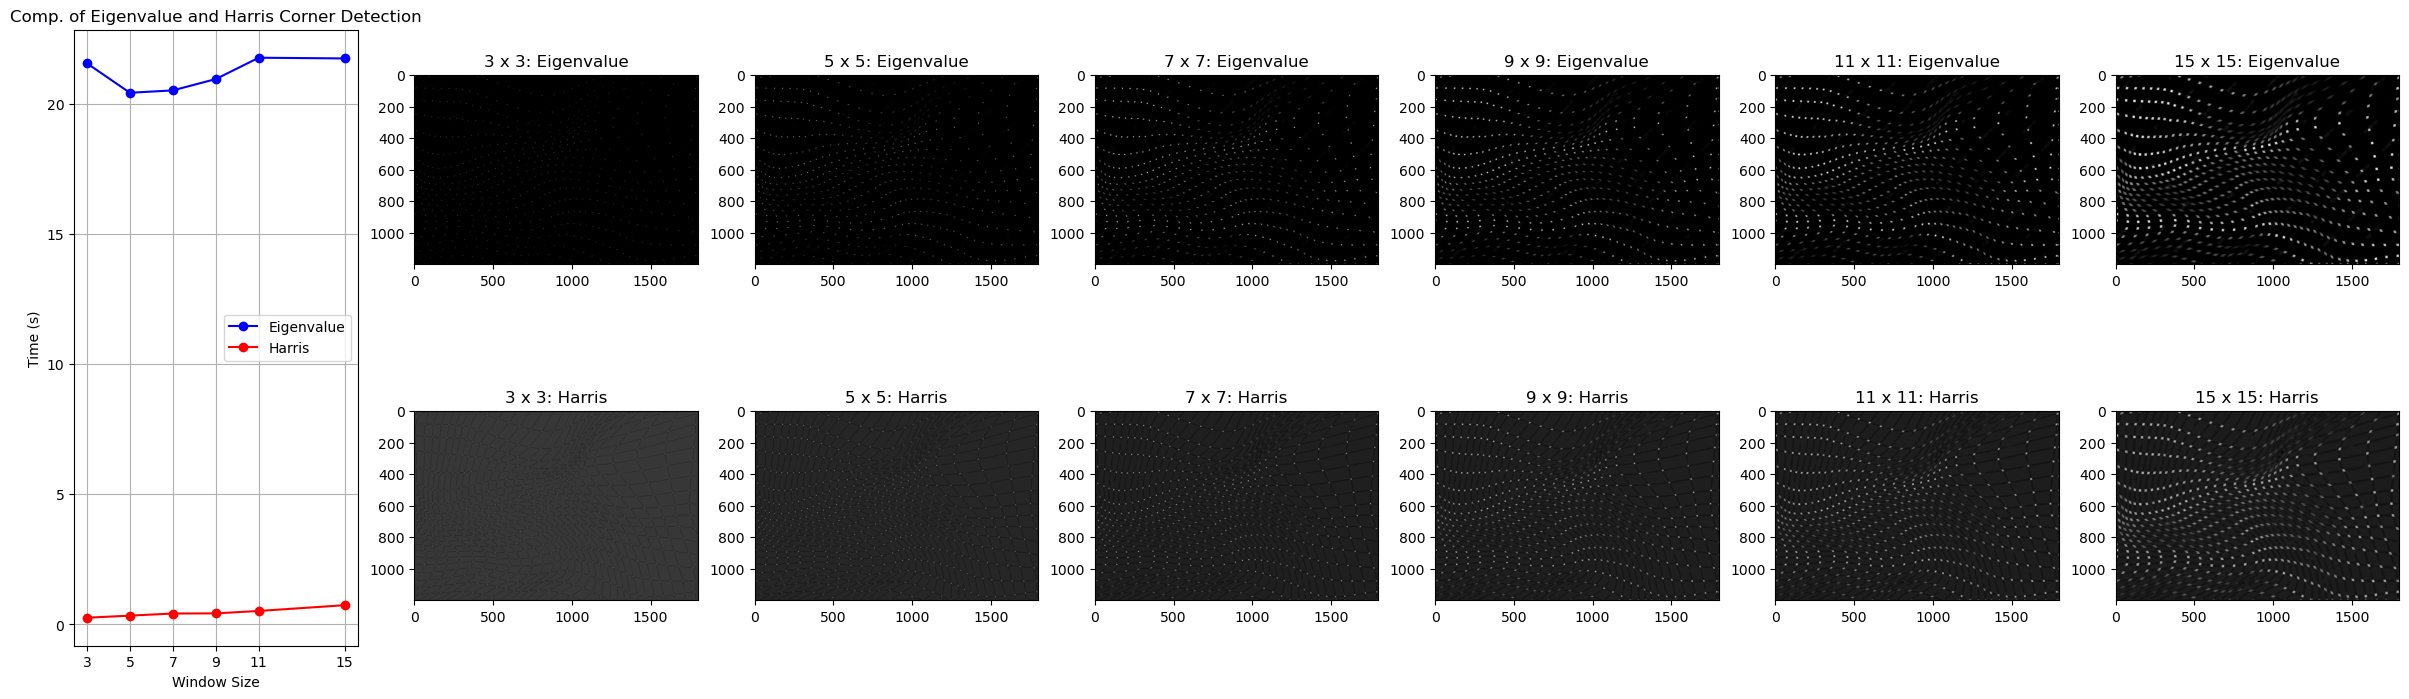

In [ ]:
"""
3 Performance Checking Functions for time recording, plot the result, and evaluate the harris/Eigenvalue corner detection performance.
starts with Measures execution time of a function.
"""
def record(func):
    start = time.time()
    result = func()
    end = time.time()
    elapsed = (end - start)
    return (result, elapsed)

"""
Creates a comprehensive visualization of corner detection results.
"""
def plot_results(title, results, indices):
    num = len(results)

    # Create figure with appropriate size
    figure = plt.figure(figsize=(5*num, 8))
    gs = gridspec.GridSpec(2, num+1, figure=figure)

    # Create timing comparison subplot (left column)
    ax_time = figure.add_subplot(gs[0:2, 0])
    ax_time.set_title(title)
    ax_time.grid(True)
    ax_time.set_xlabel('Window Size')
    ax_time.set_ylabel('Time (s)')
    ax_time.set_xticks(ticks=indices)
    ax_time.plot(indices, [result[0][1] for result in results], label='Eigenvalue', color='blue', marker='o')
    ax_time.plot(indices, [result[1][1] for result in results], label='Harris', color='red', marker='o')
    ax_time.legend(['Eigenvalue', 'Harris'])

    # Create image result subplots (grid of results)
    for (i, result) in enumerate(results):
        eigen, harris = result
        eigen_img, _ = eigen  # Extract image result and ignore timing
        harris_img, _ = harris
        
        # Top row: Eigenvalue results
        ax = figure.add_subplot(gs[0, 1+i])
        ax.set_title(f'{indices[i]} x {indices[i]}: Eigenvalue')
        ax.imshow(eigen_img, cmap='gray')

        # Bottom row: Harris results
        ax = figure.add_subplot(gs[1, i+1])
        ax.set_title(f'{indices[i]} x {indices[i]}: Harris')
        ax.imshow(harris_img, cmap='gray')
    
    plt.show()

"""
Main evaluation function for steps below!
1. Loads and preprocesses the test image
2. Tests corner detection with different window sizes
3. Records execution times
4. Visualizes all results
"""
def evaluate_corner_detection():
    # Load image and convert to grayscale
    img = plt.imread(png)
    # Convert to grayscale using ITU-R BT.601 standard weights
    img = img @ [0.2989, 0.5870, 0.1140]

    # Test both methods with various window sizes
    results = []
    window_sizes = [3, 5, 7, 9, 11, 15]
    for size in window_sizes:
        # Measure execution time for each method
        eigen = record(lambda: cornerDetect(img, winSize=size, type=0))
        harris = record(lambda: cornerDetect(img, winSize=size, type=1))
        results.append((eigen, harris))

    # Visualize all results
    plot_results('Comp. of Eigenvalue and Harris Corner Detection', results, window_sizes)

# Run the evaluation
evaluate_corner_detection()

# PART 1.3. Anser the following questions

### 1.3.1. At which window sizes can you detect all “meaningful” corners?


### 1.3.2. Which method is faster – Eigenvalue or Harris? By how much? 